<a href="https://colab.research.google.com/github/drmistretta/PredictCollege/blob/main/MLP_Validation_for_Predict_College.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copyright (c) 2022 AIClub

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated
documentation files (the "Software"), to deal in the Software without restriction, including without
limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of
the Software, and to permit persons to whom the Software is furnished to do so, subject to the following
conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial
portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT
LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO
EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN
AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE
OR OTHER DEALINGS IN THE SOFTWARE.

Follow our courses - https://www.corp.aiclub.world/courses



In [ ]:
def launch_fe(data):
    import os
    import pandas as pd
    import numpy as np
    from io import StringIO
    import json
    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import CountVectorizer
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.feature_extraction import text
    import pickle
    from scipy import sparse
    MAX_TEXT_FEATURES = 200
    columns_list = ["H5OD2A", "H1SE4", "W5REGION", "H5OD11", "H1FS1", "H1FS2", "H5PE7", "H5PE8", "H5PE1", "H5PE3", "H5PE9", "H5MN2", "H5MN3", "H5EC9"]

    dataset = pd.read_csv(data, skipinitialspace=True)

    # Replace inf and -inf, with max and min values of the particular column
    df = dataset.select_dtypes(include=np.number)
    cols = df.columns.to_series()[np.isinf(df).any()]
    col_min_max = {np.inf: dataset[cols][np.isfinite(dataset[cols])].max(), -np.inf: dataset[cols][np.isfinite(dataset[cols])].min()}
    dataset[cols] = dataset[cols].replace({col: col_min_max for col in cols})

    num_samples = len(dataset)

    # Fill values missing in categorical features
    cat_model_impute = \
        SimpleImputer(strategy='most_frequent', fill_value='missing').fit(dataset[["H5PE7", "H5PE8", "H5PE1", "H5PE3", "H5PE9", "H5MN2", "H5MN3", "H5EC9"]])
    # Save the model
    model_name = "610f5aff-7345-4fd9-b913-cf249657fde9"
    fh = open(model_name, "wb")
    pickle.dump(cat_model_impute, fh)
    fh.close()

    cat_features = ["H5PE7", "H5PE8", "H5PE1", "H5PE3", "H5PE9", "H5MN2", "H5MN3", "H5EC9"]
    dataset[cat_features] = \
        cat_model_impute.transform(dataset[cat_features])

    # One hot encode categorical values
    encode_features = ["H1SE4", "H1FS1", "H1FS2"]
    one_hot_encode_model = \
        OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(dataset[encode_features])
    # Save the model
    model_name = "c35d0f06-675a-4fe5-8308-89e9e7988d4d"
    fh = open(model_name, "wb")
    pickle.dump(one_hot_encode_model, fh)
    fh.close()

    encode_features = ["H1SE4", "H1FS1", "H1FS2"]
    new_features = \
        one_hot_encode_model.transform(dataset[encode_features])
    new_feature_names = \
        one_hot_encode_model.get_feature_names_out(encode_features)
    if (sparse.issparse(new_features)):
        new_features = new_features.toarray()
    dataframe = pd.DataFrame(new_features, columns=new_feature_names)
    dataset = dataset.drop(encode_features, axis=1)
    # reset_index to re-order the index of the new dataframe.
    dataset = pd.concat([dataset.reset_index(drop=True), dataframe.reset_index(drop=True)], axis=1)

    # Encode labels into numbers starting with 0
    label = "H5OD11"
    tmpCol = dataset[label].astype('category')
    dict_encoding = { label: dict(enumerate(tmpCol.cat.categories.astype(str)))}
    print('dict_encoding', dict_encoding)
    # Save the model
    model_name = "ab5f5bda-9f4e-450f-9972-c23a2d78bfcd"
    fh = open(model_name, "wb")
    pickle.dump(dict_encoding, fh)
    fh.close()

    label = "H5OD11"
    dataset[label] = tmpCol.cat.codes

    # Move the label column
    cols = list(dataset.columns)
    colIdx = dataset.columns.get_loc("H5OD11")
    # Do nothing if the label is in the 0th position
    # Otherwise, change the order of columns to move label to 0th position
    if colIdx != 0:
        cols = cols[colIdx:colIdx+1] + cols[0:colIdx] + cols[colIdx+1:]
        dataset = dataset[cols]

    # split dataset into train and test
    train, test = train_test_split(dataset, test_size=0.2, random_state=42)

    # Write train and test csv
    train.to_csv('train.csv', index=False, header=False)
    test.to_csv('test.csv', index=False, header=False)
    column_names = list(train.columns)
def get_model_id():
    return "ab5f5bda-9f4e-450f-9972-c23a2d78bfcd"


In [ ]:

# Upload a correct file from your local machine
from io import BytesIO
from google.colab import files
uploaded_file = files.upload()
for name in uploaded_file.keys():
    filename = name
data = BytesIO(uploaded_file[filename])


Saving full_dataset.csv to full_dataset (1).csv


In [ ]:

# Launch FE
launch_fe(data)


dict_encoding {'H5OD11': {0: 'completed college', 1: 'did not complete college'}}


In [ ]:
# Import the library of the algorithm
from sklearn.neural_network import MLPClassifier

# Initialize hyperparams
learning_rate = 0.005
hidden_layer_sizes = (100,)

# Initialize the algorithm
model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, learning_rate_init=learning_rate, random_state=0)
algorithm = 'MLPClassifier'


In [ ]:
import pandas as pd
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier  # Replace with your algorithm


# Load the test and train datasets
train = pd.read_csv('train.csv', skipinitialspace=True, header=None)
test = pd.read_csv('test.csv', skipinitialspace=True, header=None)


# Split features and target
X = train.iloc[:, 1:]
y = train.iloc[:, 0]



# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}


# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model, X, y, cv=kf, scoring=scoring, return_train_score=False)

# Display results
for metric in scoring.keys():
    print(f"{metric.capitalize()}: {results[f'test_{metric}'].mean():.4f} (+/- {results[f'test_{metric}'].std():.4f})")

model.fit(X,y)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.6778 (+/- 0.0156)
Precision: 0.6800 (+/- 0.0192)
Recall: 0.6778 (+/- 0.0156)
F1: 0.6757 (+/- 0.0190)


MLPClassifier(learning_rate_init=0.005, random_state=0)

Accuracy of the model is:  68.67469879518072


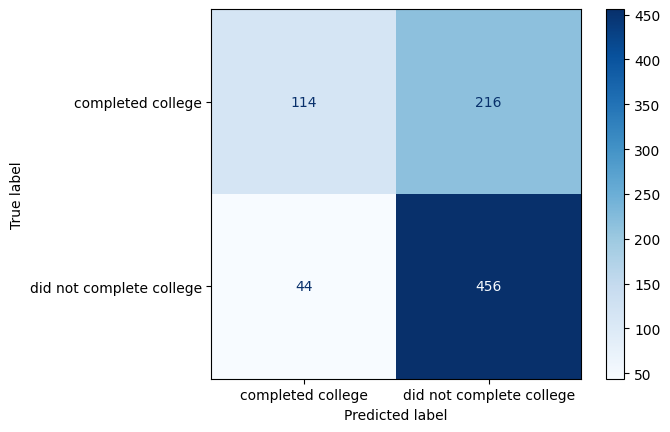

In [ ]:
# Predict the class labels
y_pred = model.predict(test.iloc[:,1:])
# import the libraries to calculate confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# calculate confusion matrix
encode_label = {"H5OD11": {"0": "completed college", "1": "did not complete college"}}
predicted_label = [*encode_label][0]
keys_list = encode_label[predicted_label].keys()
labels_display = []
labels = [int(x) for x in keys_list]
for a in range(0,len(keys_list)):
    labels_display.append(encode_label[predicted_label][str(a)])
calculated_confusion_matrix = confusion_matrix(test.iloc[:,0], y_pred, labels=labels)
cmd = ConfusionMatrixDisplay(calculated_confusion_matrix, display_labels = labels_display)
cmd.plot(cmap=plt.cm.Blues)
# calculate accuracy
score = model.score(test.iloc[:, 1:], test.iloc[:, 0])
# The value is returned as a decimal value between 0 and 1
# converting to percentage
accuracy = score * 100
print('Accuracy of the model is: ', accuracy)

In [ ]:
def encode_confusion_matrix(confusion_matrix):
    import pickle
    encoded_matrix = dict()
    object_name = get_model_id()
    file_name = open(object_name, 'rb')
    dict_encoding = pickle.load(file_name)
    labels = list(dict_encoding.values())[0]
    for row_indx, row in enumerate(confusion_matrix):
        encoded_matrix[labels[row_indx]] = {}
        for item_indx, item in enumerate(row):
            encoded_matrix[labels[row_indx]][labels[item_indx]] = item
    return encoded_matrix


In [ ]:

# fe_transform function traansforms raw data into a form the model can consume
print('Below is the prediction stage of the AI')
def fe_transform(data_dict, object_path=None):
    import os
    import pandas as pd
    from io import StringIO
    import json
    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import CountVectorizer
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.feature_extraction import text
    import pickle
    from scipy import sparse

    dataset = pd.DataFrame([data_dict])

    encode_features = ["H1SE4", "H1FS1", "H1FS2"]
    object_name = "c35d0f06-675a-4fe5-8308-89e9e7988d4d"
    file_name = open(object_name, 'rb')
    one_hot_encode_model = pickle.load(file_name)
    new_features = \
        one_hot_encode_model.transform(dataset[encode_features])
    new_feature_names = \
        one_hot_encode_model.get_feature_names_out(encode_features)
    if (sparse.issparse(new_features)):
        new_features = new_features.toarray()
    dataframe = pd.DataFrame(new_features, columns=new_feature_names)
    dataset = dataset.drop(encode_features, axis=1)
    # reset_index to re-order the index of the new dataframe.
    dataset = pd.concat([dataset.reset_index(drop=True), dataframe.reset_index(drop=True)], axis=1)

    return dataset
def encode_label_transform_predict(prediction):
    import pickle
    encoded_prediction = prediction
    label = "H5OD11"
    object_name = "ab5f5bda-9f4e-450f-9972-c23a2d78bfcd"
    file_name = open(object_name, 'rb')
    dict_encoding = pickle.load(file_name)
    label_name = list(dict_encoding.keys())[0]
    encoded_prediction = \
        dict_encoding[label_name][int(prediction)]
    print(encoded_prediction)
    return encoded_prediction
def get_labels(object_path=None):
    label_names = []
    label_name = list(dict_encoding.keys())[0]
    label_values_dict = dict_encoding[label_name]
    for key, value in label_values_dict.items():
        label_names.append(str(value))


Below is the prediction stage of the AI


In [ ]:

test_sample = {'H5OD2A': 2, 'H1SE4': '(3) About average', 'W5REGION': 4, 'H1FS1': '(0) Never/rarely', 'H1FS2': '(0) Never/rarely', 'H5PE7': 2.0, 'H5PE8': 2.0, 'H5PE1': 2.0, 'H5PE3': 2.0, 'H5PE9': 2.0, 'H5MN2': 5.0, 'H5MN3': 4.0, 'H5EC9': 5.0}
# Call FE on test_sample
test_sample_modified = fe_transform(test_sample)
# Make a prediction
prediction = model.predict(test_sample_modified)
encode_label_transform_predict(prediction)


completed college


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
<ipython-input-18-8ce13ad10668>:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dict_encoding[label_name][int(prediction)]


'completed college'

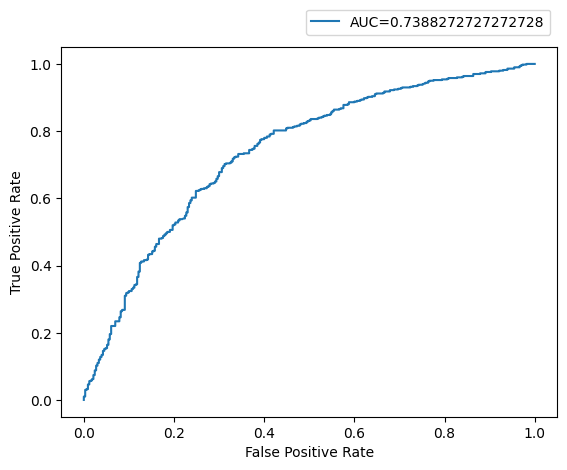

In [ ]:

# Calculate and plot roc-auc
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

encode_label = {"H5OD11": {"0": "completed college", "1": "did not complete college"}}
categories = np.unique(test.iloc[:, 0])

if algorithm and algorithm == 'LinearSVC':
    predictions = model.decision_function(test.iloc[:, 1:])
else:
    predictions = model.predict_proba(test.iloc[:, 1:])
    predictions = predictions[:, 1]

if encode_label:
    fpr, tpr, _ = roc_curve(test.iloc[:, 0], predictions)
else:
    pos_label = categories[1]
    fpr, tpr, _ = roc_curve(test.iloc[:, 0], predictions, pos_label)

auc = roc_auc_score(test.iloc[:, 0], predictions)
#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(bbox_to_anchor=(1, 1.12))
plt.show()
